<a href="https://colab.research.google.com/github/ycuayal-design/Sys2025/blob/main/taller_se%C3%B1ales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

punto 1

H(jw) = C*R1*omega/(C*omega*(R1 + R2) - I)
¿Igual a la forma estándar? -> True
w -> 0   : 0
w -> inf : C*R1/(C*R1 + C*R2)
wc = 1/((R1+R2)*C)  -> 1/(C*(R1 + R2)) rad/s


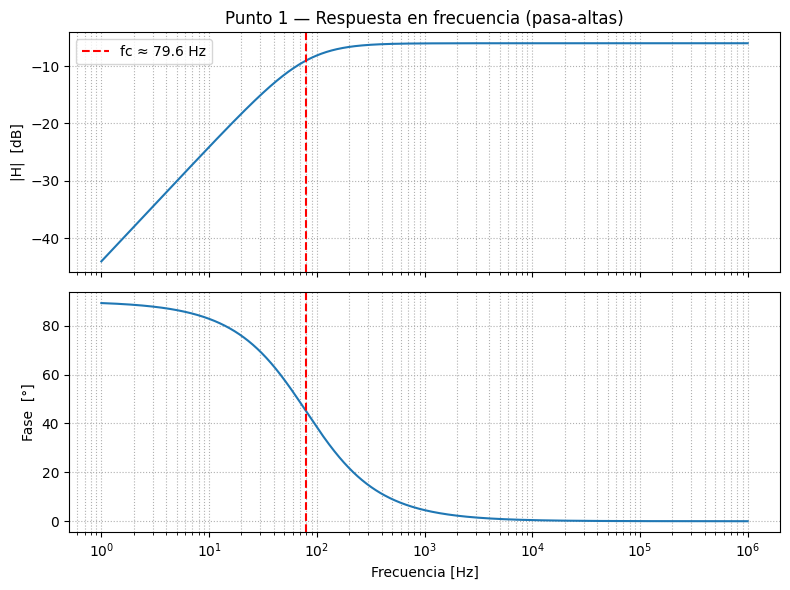

In [1]:
# ============================================================
# Punto 1 — RC con C y R2 en serie antes de R1
# Verificación simbólica + diagramas de Bode
# ============================================================
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Desarrollo simbólico ----------
w, R1, R2, C = sp.symbols('omega R1 R2 C', positive=True)
j = sp.I

Z_C = 1/(j*w*C)                 # impedancia del capacitor
H = R1 / (R1 + R2 + Z_C)        # divisor de tensión (salida sobre R1)
H = sp.simplify(H)
print("H(jw) =", H)

# ¿Coincide con la forma estándar  j*w*R1*C / (1 + j*w*(R1+R2)*C)?
H_std = (j*w*R1*C) / (1 + j*w*(R1+R2)*C)
print("¿Igual a la forma estándar? ->", sp.simplify(H - H_std) == 0)

# Límites de frecuencia
print("w -> 0   :", sp.limit(H, w, 0))      # = 0           (bloquea DC)
print("w -> inf :", sp.limit(H, w, sp.oo))  # = R1/(R1+R2)  (divisor resistivo)

# Frecuencia de corte
print("wc = 1/((R1+R2)*C)  ->", 1/((R1+R2)*C), "rad/s")

# ---------- 2) Valores numéricos (cámbialos a tu gusto) ----------
valores = {R1: 1000, R2: 1000, C: 1e-6}     # 1 kΩ, 1 kΩ, 1 µF
Hn = sp.lambdify(w, H.subs(valores), 'numpy')

fc = float((1/(2*sp.pi*(R1+R2)*C)).subs(valores))   # corte en Hz
f  = np.logspace(0, 6, 1000)                        # 1 Hz .. 1 MHz
Hf = Hn(2*np.pi*f)

mag_dB = 20*np.log10(np.abs(Hf))
fase   = np.angle(Hf, deg=True)

# ---------- 3) Gráficas de Bode ----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.semilogx(f, mag_dB)
ax1.axvline(fc, ls='--', color='r', label=f'fc ≈ {fc:.1f} Hz')
ax1.set_ylabel('|H|  [dB]'); ax1.set_title('Punto 1 — Respuesta en frecuencia (pasa-altas)')
ax1.grid(True, which='both', ls=':'); ax1.legend()

ax2.semilogx(f, fase)
ax2.axvline(fc, ls='--', color='r')
ax2.set_xlabel('Frecuencia [Hz]'); ax2.set_ylabel('Fase  [°]')
ax2.grid(True, which='both', ls=':')

plt.tight_layout(); plt.show()

punto 2

H(w) = R1/(I*L*omega + R1 + R2)
¿Igual a la forma estándar? -> True
w -> 0   : R1/(R1 + R2)
w -> inf : 0
wc = (R1+R2)/L  -> (R1 + R2)/L rad/s


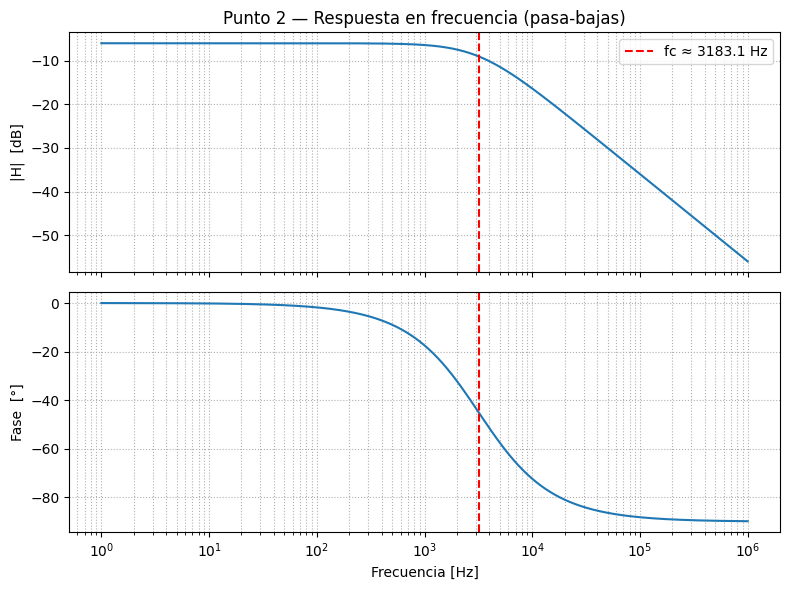

In [2]:
# ============================================================
# Punto 2 — RL con L y R2 en serie antes de R1
# Verificación simbólica + diagramas de Bode
# ============================================================
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Desarrollo simbólico ----------
w, R1, R2, L = sp.symbols('omega R1 R2 L', positive=True)
j = sp.I

Z_L = j*w*L                      # impedancia de la bobina
H = R1 / (R1 + R2 + Z_L)         # divisor de tensión (salida sobre R1)
H = sp.simplify(H)
print("H(w) =", H)

# ¿Coincide con la forma estándar  (R1/(R1+R2)) / (1 + j*w*L/(R1+R2))?
H_std = (R1/(R1+R2)) / (1 + j*w*L/(R1+R2))
print("¿Igual a la forma estándar? ->", sp.simplify(H - H_std) == 0)

# Límites de frecuencia
print("w -> 0   :", sp.limit(H, w, 0))      # = R1/(R1+R2)  (bobina = cortocircuito)
print("w -> inf :", sp.limit(H, w, sp.oo))  # = 0           (bobina bloquea)

# Frecuencia de corte
print("wc = (R1+R2)/L  ->", (R1+R2)/L, "rad/s")

# ---------- 2) Valores numéricos (cámbialos a tu gusto) ----------
valores = {R1: 1000, R2: 1000, L: 0.1}      # 1 kΩ, 1 kΩ, 0.1 H
Hn = sp.lambdify(w, H.subs(valores), 'numpy')

fc = float(((R1+R2)/L / (2*sp.pi)).subs(valores))   # corte en Hz
f  = np.logspace(0, 6, 1000)                        # 1 Hz .. 1 MHz
Hf = Hn(2*np.pi*f)

mag_dB = 20*np.log10(np.abs(Hf))
fase   = np.angle(Hf, deg=True)

# ---------- 3) Gráficas de Bode ----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.semilogx(f, mag_dB)
ax1.axvline(fc, ls='--', color='r', label=f'fc ≈ {fc:.1f} Hz')
ax1.set_ylabel('|H|  [dB]'); ax1.set_title('Punto 2 — Respuesta en frecuencia (pasa-bajas)')
ax1.grid(True, which='both', ls=':'); ax1.legend()

ax2.semilogx(f, fase)
ax2.axvline(fc, ls='--', color='r')
ax2.set_xlabel('Frecuencia [Hz]'); ax2.set_ylabel('Fase  [°]')
ax2.grid(True, which='both', ls=':')

plt.tight_layout(); plt.show()

punto 3

H(w) = (I*L*omega + R2)/(I*L*omega + R1 + R2)
¿Igual a la forma estándar? -> True
w -> 0   : R2/(R1 + R2)
w -> inf : 1
cero:  wz = R2/L      -> R2/L rad/s
polo:  wp = (R1+R2)/L -> (R1 + R2)/L rad/s


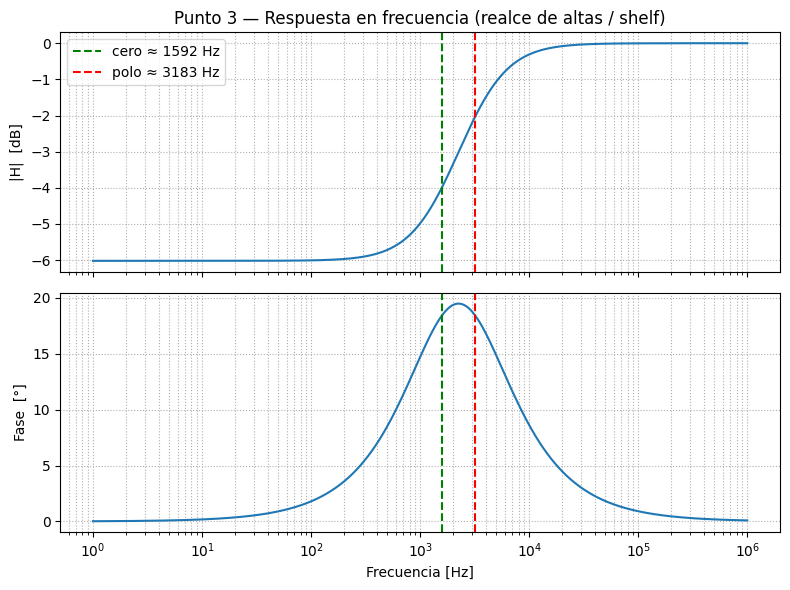

In [3]:
# ============================================================
# Punto 3 — R1 en serie con rama vertical L-R2 (salida sobre la rama)
# Verificación simbólica + diagramas de Bode
# ============================================================
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Desarrollo simbólico ----------
w, R1, R2, L = sp.symbols('omega R1 R2 L', positive=True)
j = sp.I

Z_rama = R2 + j*w*L              # impedancia de la rama vertical (L en serie con R2)
H = Z_rama / (R1 + Z_rama)       # divisor de tensión (salida sobre la rama)
H = sp.simplify(H)
print("H(w) =", H)

# ¿Coincide con la forma estándar (ganancia DC) * (1 + jwL/R2)/(1 + jwL/(R1+R2))?
H_std = (R2/(R1+R2)) * (1 + j*w*L/R2) / (1 + j*w*L/(R1+R2))
print("¿Igual a la forma estándar? ->", sp.simplify(H - H_std) == 0)

# Límites de frecuencia
print("w -> 0   :", sp.limit(H, w, 0))      # = R2/(R1+R2)  (piso en baja)
print("w -> inf :", sp.limit(H, w, sp.oo))  # = 1           (salida ~ entrada)

# Frecuencias de quiebre
print("cero:  wz = R2/L      ->", R2/L, "rad/s")
print("polo:  wp = (R1+R2)/L ->", (R1+R2)/L, "rad/s")

# ---------- 2) Valores numéricos (cámbialos a tu gusto) ----------
valores = {R1: 1000, R2: 1000, L: 0.1}      # 1 kΩ, 1 kΩ, 0.1 H
Hn = sp.lambdify(w, H.subs(valores), 'numpy')

fz = float((R2/L / (2*sp.pi)).subs(valores))        # cero en Hz
fp = float(((R1+R2)/L / (2*sp.pi)).subs(valores))   # polo en Hz
f  = np.logspace(0, 6, 1000)                        # 1 Hz .. 1 MHz
Hf = Hn(2*np.pi*f)

mag_dB = 20*np.log10(np.abs(Hf))
fase   = np.angle(Hf, deg=True)

# ---------- 3) Gráficas de Bode ----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.semilogx(f, mag_dB)
ax1.axvline(fz, ls='--', color='g', label=f'cero ≈ {fz:.0f} Hz')
ax1.axvline(fp, ls='--', color='r', label=f'polo ≈ {fp:.0f} Hz')
ax1.set_ylabel('|H|  [dB]')
ax1.set_title('Punto 3 — Respuesta en frecuencia (realce de altas / shelf)')
ax1.grid(True, which='both', ls=':'); ax1.legend()

ax2.semilogx(f, fase)
ax2.axvline(fz, ls='--', color='g')
ax2.axvline(fp, ls='--', color='r')
ax2.set_xlabel('Frecuencia [Hz]'); ax2.set_ylabel('Fase  [°]')
ax2.grid(True, which='both', ls=':')

plt.tight_layout(); plt.show()

punto 4

H(w) = R1*(I*L*omega + R0)/(I*L*R0*omega + R1*(I*L*omega + R0))
¿Igual a la forma estándar? -> True
w -> 0   : 1
w -> inf : I*L*R1/(I*L*R0 + I*L*R1)
polo:  wp = R0*R1/(L*(R0+R1)) -> R0*R1/(L*(R0 + R1)) rad/s
cero:  wz = R0/L              -> R0/L rad/s


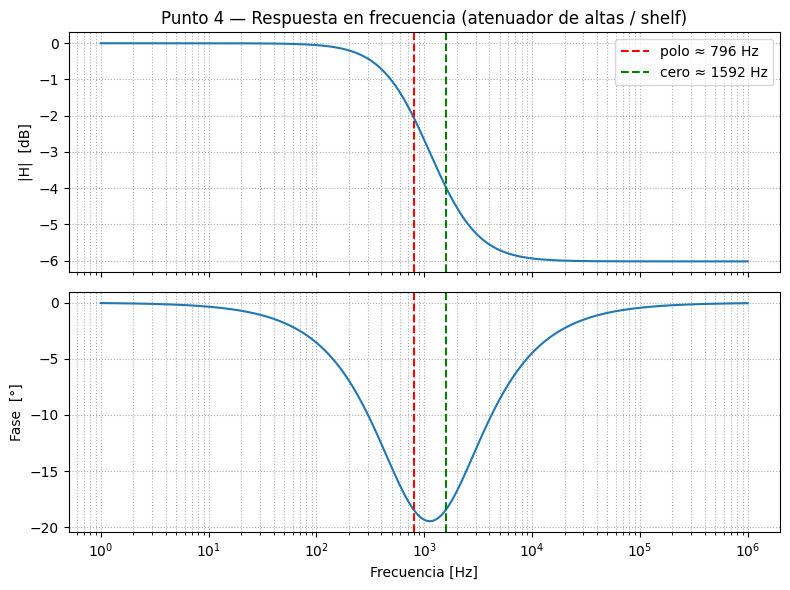

In [4]:
# ============================================================
# Punto 4 — R0 en paralelo con L, en serie con R1 (salida sobre R1)
# Verificación simbólica + diagramas de Bode
# ============================================================
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Desarrollo simbólico ----------
w, R0, R1, L = sp.symbols('omega R0 R1 L', positive=True)
j = sp.I

Z_par = (R0 * j*w*L) / (R0 + j*w*L)     # impedancia del paralelo R0 || L
H = R1 / (R1 + Z_par)                    # divisor de tensión (salida sobre R1)
H = sp.simplify(H)
print("H(w) =", H)

# ¿Coincide con la forma estándar (1 + jwL/R0) / (1 + jwL(R0+R1)/(R0*R1))?
H_std = (1 + j*w*L/R0) / (1 + j*w*L*(R0+R1)/(R0*R1))
print("¿Igual a la forma estándar? ->", sp.simplify(H - H_std) == 0)

# Límites de frecuencia
print("w -> 0   :", sp.limit(H, w, 0))      # = 1            (bobina en corto -> bloque = cable)
print("w -> inf :", sp.limit(H, w, sp.oo))  # = R1/(R0+R1)   (bobina abierta -> divisor con R0)

# Frecuencias de quiebre
print("polo:  wp = R0*R1/(L*(R0+R1)) ->", R0*R1/(L*(R0+R1)), "rad/s")
print("cero:  wz = R0/L              ->", R0/L, "rad/s")

# ---------- 2) Valores numéricos (cámbialos a tu gusto) ----------
valores = {R0: 1000, R1: 1000, L: 0.1}      # 1 kΩ, 1 kΩ, 0.1 H
Hn = sp.lambdify(w, H.subs(valores), 'numpy')

fp = float((R0*R1/(L*(R0+R1)) / (2*sp.pi)).subs(valores))   # polo en Hz
fz = float((R0/L / (2*sp.pi)).subs(valores))                # cero en Hz
f  = np.logspace(0, 6, 1000)                                # 1 Hz .. 1 MHz
Hf = Hn(2*np.pi*f)

mag_dB = 20*np.log10(np.abs(Hf))
fase   = np.angle(Hf, deg=True)

# ---------- 3) Gráficas de Bode ----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.semilogx(f, mag_dB)
ax1.axvline(fp, ls='--', color='r', label=f'polo ≈ {fp:.0f} Hz')
ax1.axvline(fz, ls='--', color='g', label=f'cero ≈ {fz:.0f} Hz')
ax1.set_ylabel('|H|  [dB]')
ax1.set_title('Punto 4 — Respuesta en frecuencia (atenuador de altas / shelf)')
ax1.grid(True, which='both', ls=':'); ax1.legend()

ax2.semilogx(f, fase)
ax2.axvline(fp, ls='--', color='r')
ax2.axvline(fz, ls='--', color='g')
ax2.set_xlabel('Frecuencia [Hz]'); ax2.set_ylabel('Fase  [°]')
ax2.grid(True, which='both', ls=':')

plt.tight_layout(); plt.show()

punto 5

In [6]:
# ============================================================
# Punto 5 — R1 en serie con rama vertical C-R2 (salida sobre la rama)
# Verificación simbólica + diagramas de Bode
# ============================================================
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Desarrollo simbólico ----------
w, R1, R2, C = sp.symbols('omega R1 R2 C', positive=True)
j = sp.I

Z_rama = R2 + 1/(j*w*C)          # rama vertical: C en serie con R2
H = Z_rama / (R1 + Z_rama)       # divisor de tensión (salida sobre la rama)
H = sp.simplify(H)
print("H(w) =", H)

# ¿Coincide con la forma estándar (1 + jwR2C)/(1 + jw(R1+R2)C)?
H_std = (1 + j*w*R2*C) / (1 + j*w*(R1+R2)*C)
print("¿Igual a la forma estándar? ->", sp.simplify(H - H_std) == 0)

# Límites de frecuencia
print("w -> 0   :", sp.limit(H, w, 0))      # = 1           (capacitor abierto -> vout = vin)
print("w -> inf :", sp.limit(H, w, sp.oo))  # = R2/(R1+R2)  (capacitor en corto -> divisor)

# Frecuencias de quiebre
print("polo:  wp = 1/((R1+R2)C) ->", 1/((R1+R2)*C), "rad/s")
print("cero:  wz = 1/(R2 C)     ->", 1/(R2*C), "rad/s")

# ---------- 2) Valores numéricos (cámbialos a tu gusto) ----------
valores = {R1: 1000, R2: 1000, C: 1e-6}     # 1 kΩ, 1 kΩ, 1 µF
Hn = sp.lambdify(w, H.subs(valores), 'numpy')

fp = float((1/((R1+R2)*C) / (2*sp.pi)).subs(valores))   # polo en

H(w) = (C*R2*omega - I)/(C*omega*(R1 + R2) - I)
¿Igual a la forma estándar? -> True
w -> 0   : 1
w -> inf : C*R2/(C*R1 + C*R2)
polo:  wp = 1/((R1+R2)C) -> 1/(C*(R1 + R2)) rad/s
cero:  wz = 1/(R2 C)     -> 1/(C*R2) rad/s


punto 6

H(w) = L*R2*omega/(L*R1*omega + L*R2*omega - I*R1*R2)
w -> 0   : 0
w -> inf : L*R2/(L*R1 + L*R2)
wc = R1*R2/(L*(R1+R2)) -> R1*R2/(L*(R1 + R2))


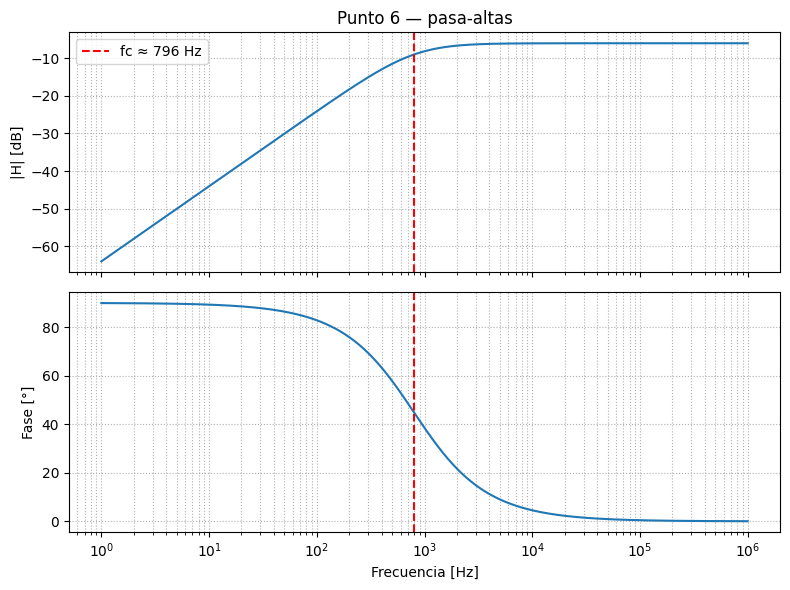

In [7]:
import sympy as sp, numpy as np, matplotlib.pyplot as plt
w, R1, R2, L = sp.symbols('omega R1 R2 L', positive=True); j = sp.I

Z_par = (j*w*L * R2) / (R2 + j*w*L)     # L en paralelo con R2 (a tierra)
H = sp.simplify(Z_par / (R1 + Z_par))   # salida = voltaje del nodo
print("H(w) =", H)
print("w -> 0   :", sp.limit(H, w, 0))      # 0            (bobina manda bajas a tierra)
print("w -> inf :", sp.limit(H, w, sp.oo))  # R2/(R1+R2)
print("wc = R1*R2/(L*(R1+R2)) ->", R1*R2/(L*(R1+R2)))

valores = {R1: 1000, R2: 1000, L: 0.1}
Hn = sp.lambdify(w, H.subs(valores), 'numpy')
fc = float((R1*R2/(L*(R1+R2)) / (2*sp.pi)).subs(valores))
f = np.logspace(0, 6, 1000); Hf = Hn(2*np.pi*f)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
a1.semilogx(f, 20*np.log10(np.abs(Hf))); a1.axvline(fc, ls='--', color='r', label=f'fc ≈ {fc:.0f} Hz')
a1.set_ylabel('|H| [dB]'); a1.set_title('Punto 6 — pasa-altas'); a1.grid(True, which='both', ls=':'); a1.legend()
a2.semilogx(f, np.angle(Hf, deg=True)); a2.axvline(fc, ls='--', color='r')
a2.set_xlabel('Frecuencia [Hz]'); a2.set_ylabel('Fase [°]'); a2.grid(True, which='both', ls=':')
plt.tight_layout(); plt.show()

punto 7

H(w) = R2/(R1*(I*C*R2*omega + 1) + R2)
w -> 0   : R2/(R1 + R2)
w -> inf : 0
wc = (R1+R2)/(R1*R2*C) -> (R1 + R2)/(C*R1*R2)


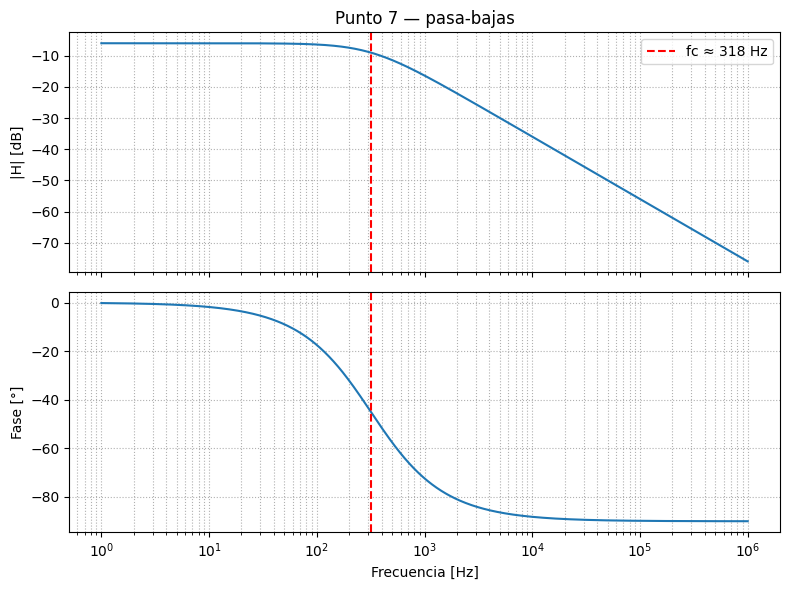

In [11]:
import sympy as sp, numpy as np, matplotlib.pyplot as plt
w, R1, R2, C = sp.symbols('omega R1 R2 C', positive=True); j = sp.I

Z_par = R2 / (1 + j*w*R2*C)              # C en paralelo con R2 (a tierra)
H = sp.simplify(Z_par / (R1 + Z_par))
print("H(w) =", H)
print("w -> 0   :", sp.limit(H, w, 0))      # R2/(R1+R2)
print("w -> inf :", sp.limit(H, w, sp.oo))  # 0          (capacitor manda altas a tierra)
print("wc = (R1+R2)/(R1*R2*C) ->", (R1+R2)/(R1*R2*C))

valores = {R1: 1000, R2: 1000, C: 1e-6}
Hn = sp.lambdify(w, H.subs(valores), 'numpy')
fc = float(((R1+R2)/(R1*R2*C) / (2*sp.pi)).subs(valores))
f = np.logspace(0, 6, 1000); Hf = Hn(2*np.pi*f)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
a1.semilogx(f, 20*np.log10(np.abs(Hf))); a1.axvline(fc, ls='--', color='r', label=f'fc ≈ {fc:.0f} Hz')
a1.set_ylabel('|H| [dB]'); a1.set_title('Punto 7 — pasa-bajas'); a1.grid(True, which='both', ls=':'); a1.legend()
a2.semilogx(f, np.angle(Hf, deg=True)); a2.axvline(fc, ls='--', color='r')
a2.set_xlabel('Frecuencia [Hz]'); a2.set_ylabel('Fase [°]'); a2.grid(True, which='both', ls=':')
plt.tight_layout(); plt.show()

punto 8

H(w) = R1/(R1 + R2/(I*C*R2*omega + 1))
w -> 0   : R1/(R1 + R2)
w -> inf : 1
cero: wz = 1/(R2 C)         -> 1/(C*R2)
polo: wp = (R1+R2)/(R1 R2 C)-> (R1 + R2)/(C*R1*R2)


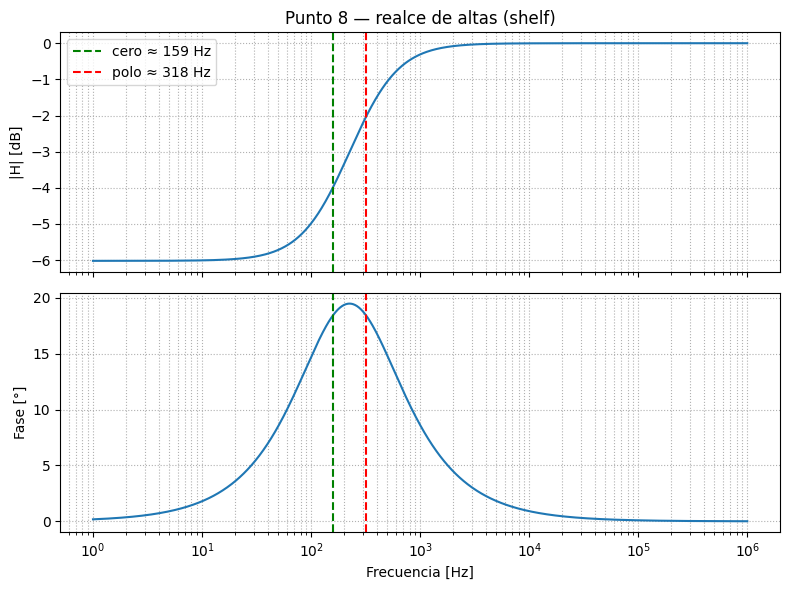

In [10]:
import sympy as sp, numpy as np, matplotlib.pyplot as plt
w, R1, R2, C = sp.symbols('omega R1 R2 C', positive=True); j = sp.I

Z_par = R2 / (1 + j*w*R2*C)              # C en paralelo con R2 (bloque antes de R1)
H = sp.simplify(R1 / (R1 + Z_par))       # salida sobre R1
print("H(w) =", H)
print("w -> 0   :", sp.limit(H, w, 0))      # R1/(R1+R2)   (piso)
print("w -> inf :", sp.limit(H, w, sp.oo))  # 1
print("cero: wz = 1/(R2 C)         ->", 1/(R2*C))
print("polo: wp = (R1+R2)/(R1 R2 C)->", (R1+R2)/(R1*R2*C))

valores = {R1: 1000, R2: 1000, C: 1e-6}
Hn = sp.lambdify(w, H.subs(valores), 'numpy')
fz = float((1/(R2*C) / (2*sp.pi)).subs(valores)); fp = float(((R1+R2)/(R1*R2*C) / (2*sp.pi)).subs(valores))
f = np.logspace(0, 6, 1000); Hf = Hn(2*np.pi*f)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
a1.semilogx(f, 20*np.log10(np.abs(Hf)))
a1.axvline(fz, ls='--', color='g', label=f'cero ≈ {fz:.0f} Hz'); a1.axvline(fp, ls='--', color='r', label=f'polo ≈ {fp:.0f} Hz')
a1.set_ylabel('|H| [dB]'); a1.set_title('Punto 8 — realce de altas (shelf)'); a1.grid(True, which='both', ls=':'); a1.legend()
a2.semilogx(f, np.angle(Hf, deg=True)); a2.axvline(fz, ls='--', color='g'); a2.axvline(fp, ls='--', color='r')
a2.set_xlabel('Frecuencia [Hz]'); a2.set_ylabel('Fase [°]'); a2.grid(True, which='both', ls=':')
plt.tight_layout(); plt.show()

punto 9

H(w) = R1*(I*L*omega + R2)/(I*L*R2*omega + R1*(I*L*omega + R2))
w -> 0   : 1
w -> inf : I*L*R1/(I*L*R1 + I*L*R2)
cero: wz = R2/L              -> R2/L
polo: wp = R1*R2/(L*(R1+R2)) -> R1*R2/(L*(R1 + R2))


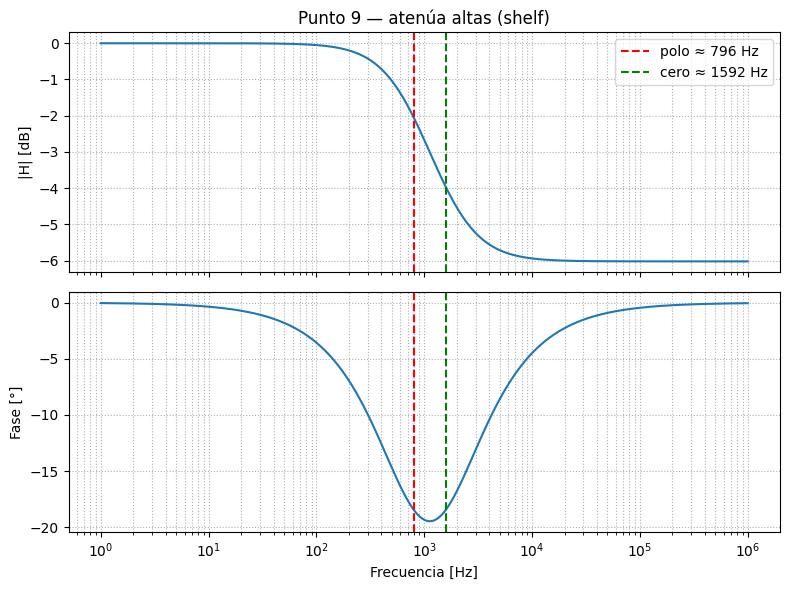

In [9]:
import sympy as sp, numpy as np, matplotlib.pyplot as plt
w, R1, R2, L = sp.symbols('omega R1 R2 L', positive=True); j = sp.I

Z_par = (j*w*L * R2) / (R2 + j*w*L)      # L en paralelo con R2 (bloque antes de R1)
H = sp.simplify(R1 / (R1 + Z_par))       # salida sobre R1
print("H(w) =", H)
print("w -> 0   :", sp.limit(H, w, 0))      # 1
print("w -> inf :", sp.limit(H, w, sp.oo))  # R1/(R1+R2)   (piso)
print("cero: wz = R2/L              ->", R2/L)
print("polo: wp = R1*R2/(L*(R1+R2)) ->", R1*R2/(L*(R1+R2)))

valores = {R1: 1000, R2: 1000, L: 0.1}
Hn = sp.lambdify(w, H.subs(valores), 'numpy')
fz = float((R2/L / (2*sp.pi)).subs(valores)); fp = float((R1*R2/(L*(R1+R2)) / (2*sp.pi)).subs(valores))
f = np.logspace(0, 6, 1000); Hf = Hn(2*np.pi*f)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
a1.semilogx(f, 20*np.log10(np.abs(Hf)))
a1.axvline(fp, ls='--', color='r', label=f'polo ≈ {fp:.0f} Hz'); a1.axvline(fz, ls='--', color='g', label=f'cero ≈ {fz:.0f} Hz')
a1.set_ylabel('|H| [dB]'); a1.set_title('Punto 9 — atenúa altas (shelf)'); a1.grid(True, which='both', ls=':'); a1.legend()
a2.semilogx(f, np.angle(Hf, deg=True)); a2.axvline(fp, ls='--', color='r'); a2.axvline(fz, ls='--', color='g')
a2.set_xlabel('Frecuencia [Hz]'); a2.set_ylabel('Fase [°]'); a2.grid(True, which='both', ls=':')
plt.tight_layout(); plt.show()

punto 10

H(w) = -I/(C*omega*(I*L*omega + R) - I)
w -> 0   : 1
w -> inf : 0
w0 = 1/sqrt(LC)        -> 1/(sqrt(C)*sqrt(L))
Q  = (1/R)*sqrt(L/C)   -> sqrt(L)/(sqrt(C)*R)


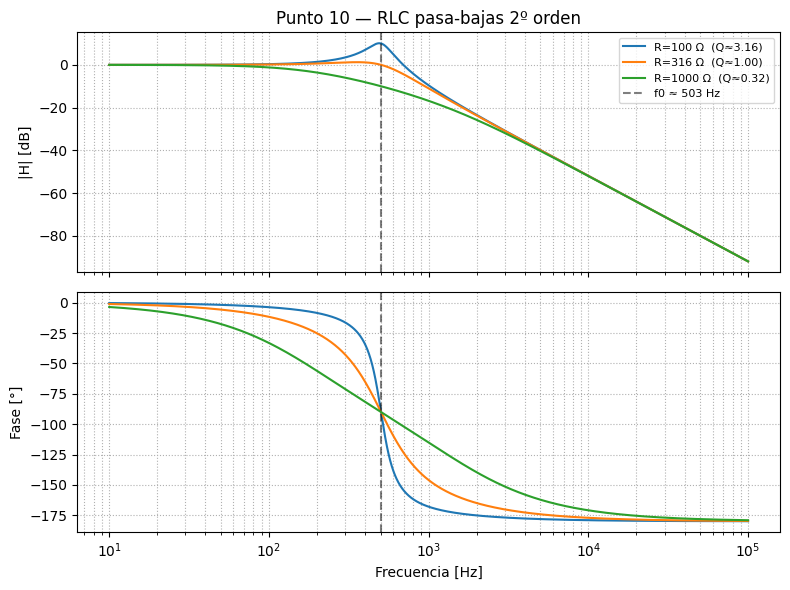

In [8]:
import sympy as sp, numpy as np, matplotlib.pyplot as plt
w, R, L, C = sp.symbols('omega R L C', positive=True); j = sp.I

Z_C = 1/(j*w*C)
H = sp.simplify(Z_C / (R + j*w*L + Z_C))     # salida sobre el capacitor
print("H(w) =", H)
print("w -> 0   :", sp.limit(H, w, 0))       # 1
print("w -> inf :", sp.limit(H, w, sp.oo))   # 0  (cae a -40 dB/dec)
print("w0 = 1/sqrt(LC)        ->", 1/sp.sqrt(L*C))
print("Q  = (1/R)*sqrt(L/C)   ->", sp.sqrt(L/C)/R)

# ---- Variamos R para ver distintos Q (mismo w0) ----
L_, C_ = 0.1, 1e-6
w0 = 1/np.sqrt(L_*C_); f0 = w0/(2*np.pi)
f = np.logspace(1, 5, 2000)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for R_ in [100, 316, 1000]:
    Q = (1/R_)*np.sqrt(L_/C_)
    Hn = sp.lambdify(w, H.subs({R: R_, L: L_, C: C_}), 'numpy')
    Hf = Hn(2*np.pi*f)
    a1.semilogx(f, 20*np.log10(np.abs(Hf)), label=f'R={R_} Ω  (Q≈{Q:.2f})')
    a2.semilogx(f, np.angle(Hf, deg=True))
a1.axvline(f0, ls='--', color='k', alpha=0.5, label=f'f0 ≈ {f0:.0f} Hz')
a1.set_ylabel('|H| [dB]'); a1.set_title('Punto 10 — RLC pasa-bajas 2º orden'); a1.grid(True, which='both', ls=':'); a1.legend(fontsize=8)
a2.axvline(f0, ls='--', color='k', alpha=0.5)
a2.set_xlabel('Frecuencia [Hz]'); a2.set_ylabel('Fase [°]'); a2.grid(True, which='both', ls=':')
plt.tight_layout(); plt.show()